In [12]:
import fiftyone as fo 
import fiftyone.brain as fob # ML methods
import fiftyone.zoo as foz # zoo datasets and models
from fiftyone import ViewField as F # helper for defining views
import os

In [13]:
OBJECT="socket_pin"

# Initialize Dataset
if "socket_dataset" in fo.list_datasets():
    fo.delete_dataset("socket_dataset")
dataset = fo.Dataset("socket_dataset")

samples = []
data_path = "./datasets/socket_pins"

train_dir = os.path.join(data_path, "train", "good")
if os.path.exists(train_dir):
    for file in os.listdir(train_dir):
        if file.lower().endswith(('.jpg', '.png')):
            sample = fo.Sample(filepath=os.path.join(train_dir, file))
            sample["split"] = "train"
            sample["category"] = fo.Classification(label=OBJECT)
            sample["state"] = fo.Classification(label="good")
            samples.append(sample)

test_good_dir = os.path.join(data_path, "test", "good")
if os.path.exists(test_good_dir):
    for file in os.listdir(test_good_dir):
        if file.lower().endswith(('.jpg', '.png')):
            sample = fo.Sample(filepath=os.path.join(test_good_dir, file))
            sample["split"] = "test"
            sample["category"] = fo.Classification(label=OBJECT)
            sample["state"] = fo.Classification(label="good")
            samples.append(sample)

dataset.add_samples(samples)
print(f"Loaded {len(samples)} samples.")

 100% |█████████████████| 353/353 [95.3ms elapsed, 0s remaining, 3.7K samples/s]   


INFO:eta.core.utils: 100% |█████████████████| 353/353 [95.3ms elapsed, 0s remaining, 3.7K samples/s]   


Loaded 353 samples.


In [14]:
""" model = foz.load_zoo_model("clip-vit-base32-torch") """
model = foz.load_zoo_model("resnet50-imagenet-torch")

# Compute embeddings for the dataset
""" dataset.compute_embeddings(model=model, embeddings_field="clip_embeddings") """
dataset.compute_embeddings(model=model, embeddings_field="resnet50_embeddings")

# Dimensionality reduction using UMAP on the embeddings
fob.compute_visualization(dataset, embeddings="resnet50_embeddings", method="umap", brain_key="resnet50_vis")

 100% |█████████████████| 353/353 [3.8s elapsed, 0s remaining, 92.4 samples/s]       


INFO:eta.core.utils: 100% |█████████████████| 353/353 [3.8s elapsed, 0s remaining, 92.4 samples/s]       


Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...


UMAP( verbose=True)
Sun Jan  4 21:35:57 2026 Construct fuzzy simplicial set
Sun Jan  4 21:35:57 2026 Finding Nearest Neighbors
Sun Jan  4 21:35:57 2026 Finished Nearest Neighbor Search
Sun Jan  4 21:35:57 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun Jan  4 21:35:57 2026 Finished embedding


In [15]:
from sklearn.cluster import KMeans, HDBSCAN
import numpy as np

In [16]:
# Extract the embeddings from the dataset
embeddings = np.array(dataset.values("resnet50_embeddings"))

# KMeans clustering
num_clusters = 4 
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

# Add the cluster IDs back to the dataset as a new field
dataset.set_values("cluster_id", [str(c) for c in clusters])
print(f"Assigned {len(clusters)} samples to {num_clusters} clusters.")

# HDBSCAN clustering
hdbscan = HDBSCAN(min_cluster_size=5, metric='euclidean')
clusters_hbd = hdbscan.fit_predict(embeddings)

dataset.set_values("cluster_id_hdb", [str(c) for c in clusters_hbd])
print(f"Assigned {len(clusters_hbd)} samples to clusters.")

Assigned 353 samples to 4 clusters.
Assigned 353 samples to clusters.


In [17]:
""" cluster_1_view = dataset.match(F("cluster_id") == "1")
for sample in cluster_1_view:
    sample["state"].label = "missalinged/non-pin"
    sample.save() 

cluster_2_view = dataset.match(F("cluster_id") == "0")
for sample in cluster_2_view:
    sample["state"].label = "hole"
    sample.save()

cluster_3_view = dataset.match(F("cluster_id") == "2")
for sample in cluster_3_view:
    sample["state"].label = "pin"
    sample.save()  """

' cluster_1_view = dataset.match(F("cluster_id") == "1")\nfor sample in cluster_1_view:\n    sample["state"].label = "missalinged/non-pin"\n    sample.save() \n\ncluster_2_view = dataset.match(F("cluster_id") == "0")\nfor sample in cluster_2_view:\n    sample["state"].label = "hole"\n    sample.save()\n\ncluster_3_view = dataset.match(F("cluster_id") == "2")\nfor sample in cluster_3_view:\n    sample["state"].label = "pin"\n    sample.save()  '

In [ ]:
session = fo.launch_app(dataset)

In [19]:
from anomalib.data import Folder
from anomalib.models import Padim, Patchcore
from anomalib.engine import Engine
from anomalib import TaskType
import anomalib.models.components.sampling.k_center_greedy as k_center
from tqdm.notebook import tqdm
k_center.tqdm = tqdm
import torch
from torchvision.transforms.v2 import Resize
torch.set_float32_matmul_precision('medium')
# When initializing the Engine, replace the default progress bar
from lightning.pytorch.callbacks import TQDMProgressBar
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

In [20]:
def train_socket_inspector():    
    model = Patchcore(
        backbone="resnet34",  # Consistent with config
        layers=["layer2", "layer3"],
        coreset_sampling_ratio=0.25,  # Increased for better coverage
        num_neighbors=15,  # Increased for better scoring
    )
    
    datamodule = Folder(
        name="socket_pins",
        root="./datasets/socket_pins",
        normal_dir="train/good",
        abnormal_dir="test/defect",
        num_workers=8,
    )
    
    
    """ checkpoint_callback = ModelCheckpoint(
        dirpath="results/Patchcore/socket_pins/checkpoints",
        filename="best-{epoch:02d}-{image_F1Score:.2f}",
        save_top_k=3,
        monitor="image_F1Score",
        mode="max",
    )
    
    early_stop_callback = EarlyStopping(
        monitor="image_F1Score",
        patience=5,
        mode="max",
    ) """
    
    """
    model = Padim(backbone="resnet34")
    datamodule = Folder(
        name="socket_pins",
        root="./datasets/socket_pins",
        normal_dir="train/good",
        # abnormal_dir="test/defect",
        num_workers=8,
    )
    """

    engine = Engine(callbacks=[TQDMProgressBar()], max_epochs=50)
    """ callbacks=[checkpoint_callback, early_stop_callback], """
    
    engine.fit(datamodule=datamodule, model=model)
    engine.test(datamodule=datamodule, model=model)
    
    # Export with pixel-level predictions
    engine.export(
        model=model,
        export_type="torch",
        ckpt_path="./results/Patchcore/socket_pins/latest/weights/lightning/model.ckpt",
    )
    print("Model exported to .pt format successfully.")

train_socket_inspector()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim_detector\Lib\site-packages\lightning\pytorch\core\optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │  8.2 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 8.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.2 M                                                                                                
Total estimated model params size (MB): 32                                                                         
Modules in train mode: 19                                                                                          
Modules in eval mode: 132                                                                                          
Total FLOPs: 0

c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim_detector\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.
c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim_detector\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim_detector\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 132 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_epochs=1` reached.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim_detector\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing: |          | 0/? [00:00<?, ?it/s]

c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim_detector\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: The ``compute`` method of metric AUROC was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)
c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim_detector\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: The ``compute`` method of metric F1Score was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.6464285254478455     │
│       image_F1Score       │    0.7142857313156128     │
└───────────────────────────┴───────────────────────────┘

Model exported to .pt format successfully.


In [21]:
from anomalib.deploy import TorchInferencer, OpenVINOInferencer
import cv2
import matplotlib.pyplot as plt
import dotenv
dotenv.load_dotenv()

True

Anomalous


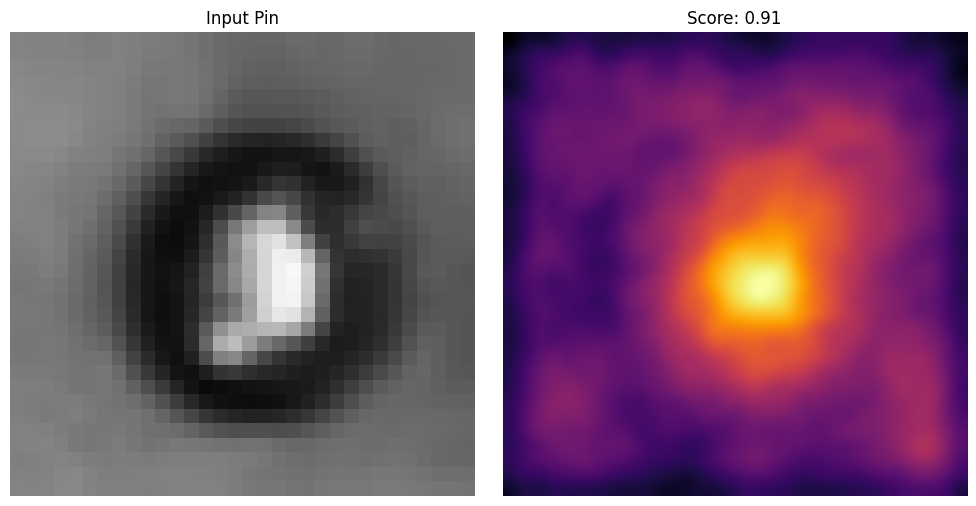

Good


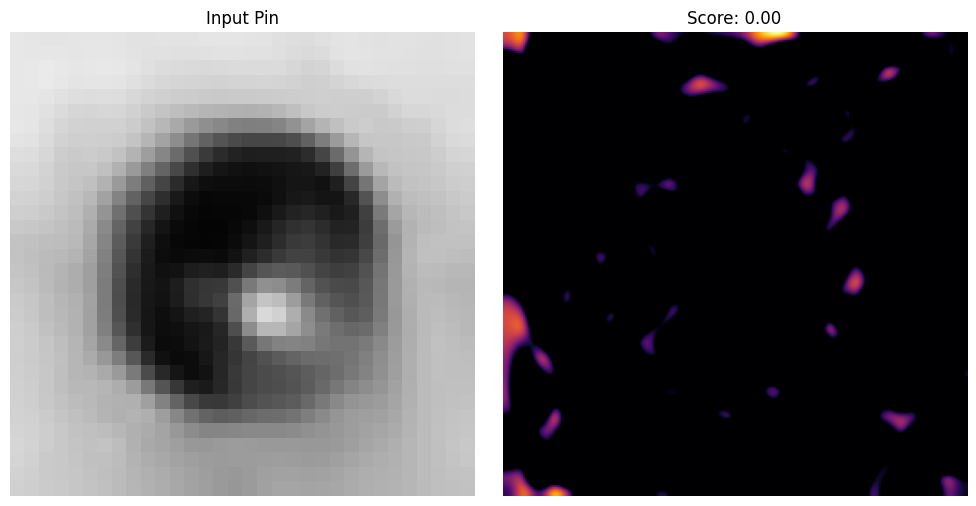

Good


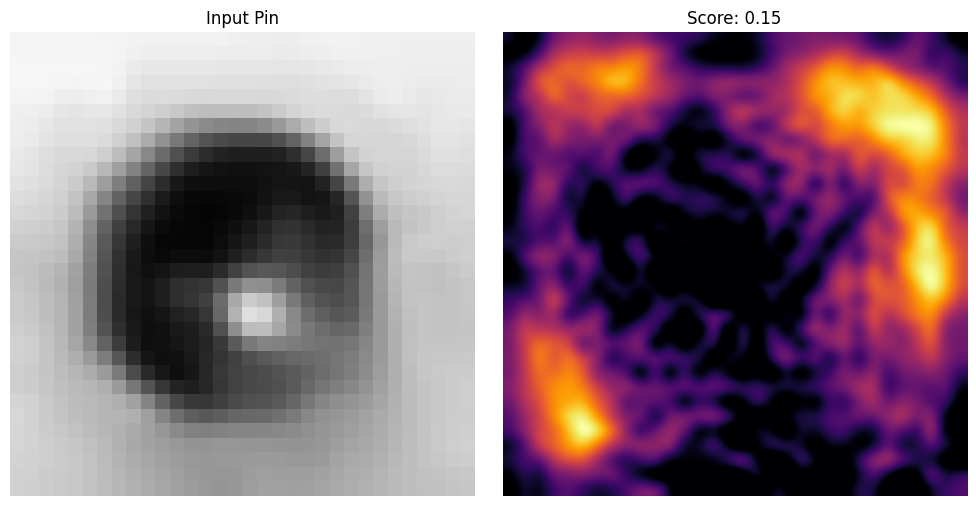

Anomalous


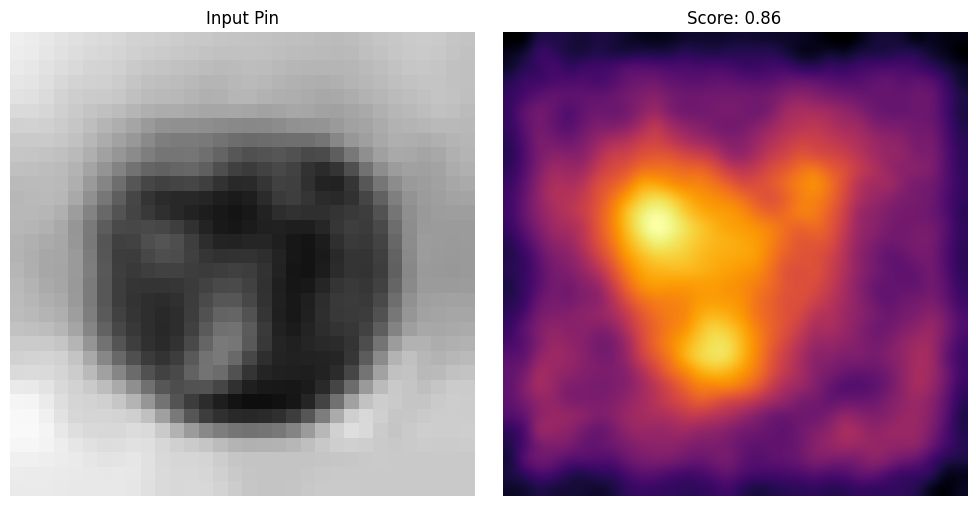

Anomalous


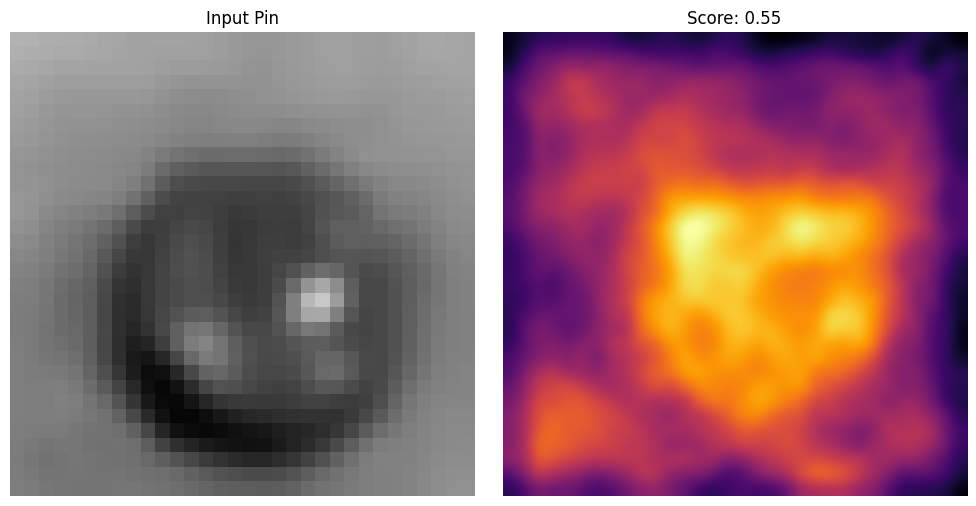

Anomalous


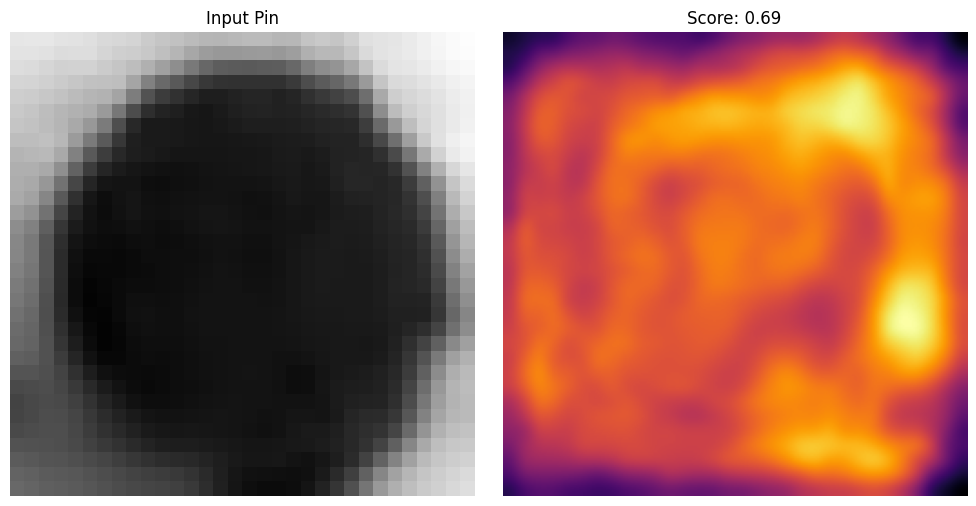

Anomalous


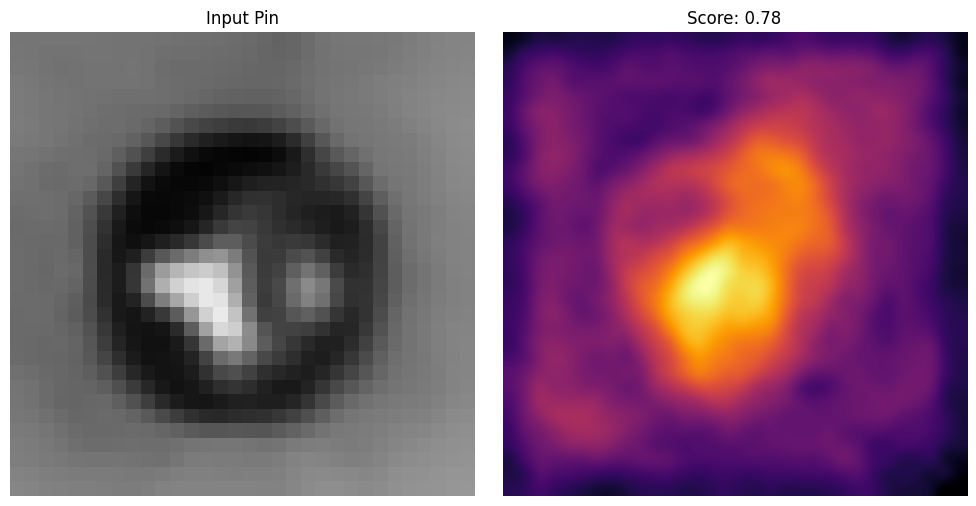

Anomalous


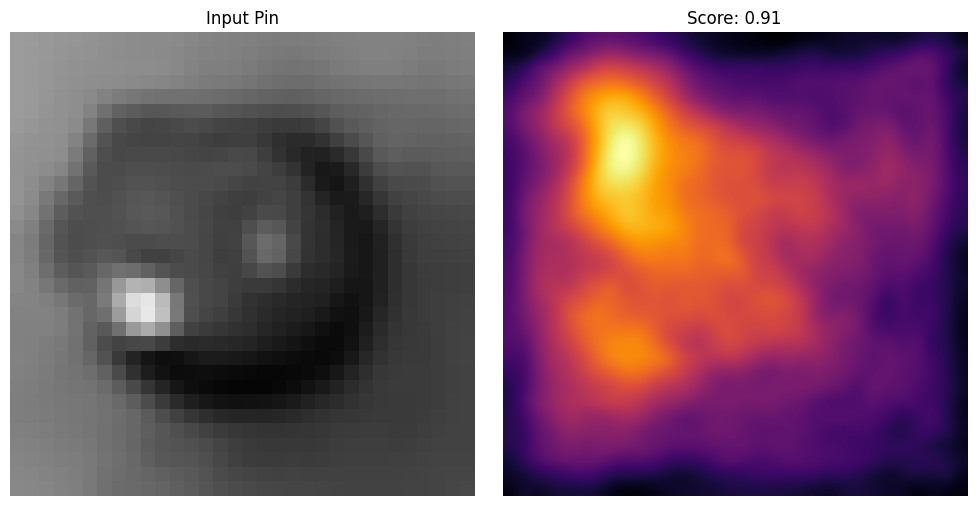

Good


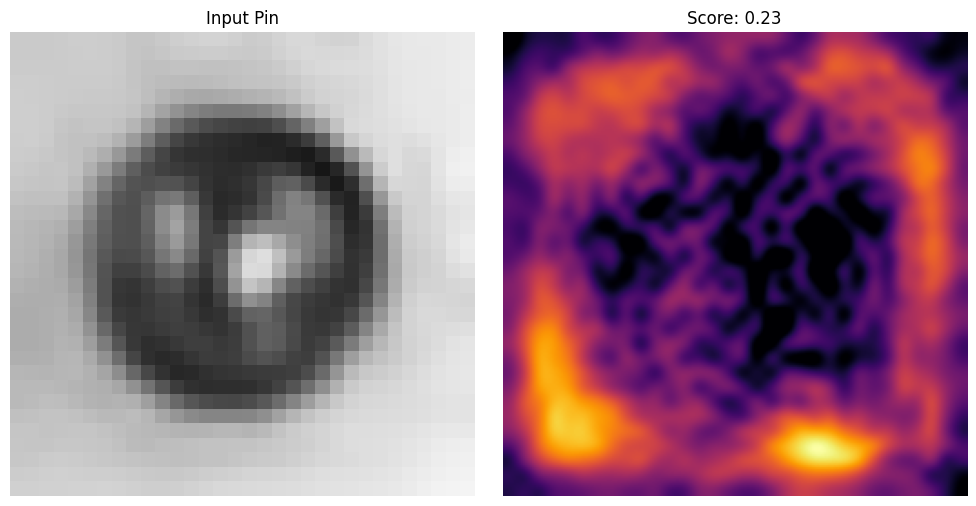

Anomalous


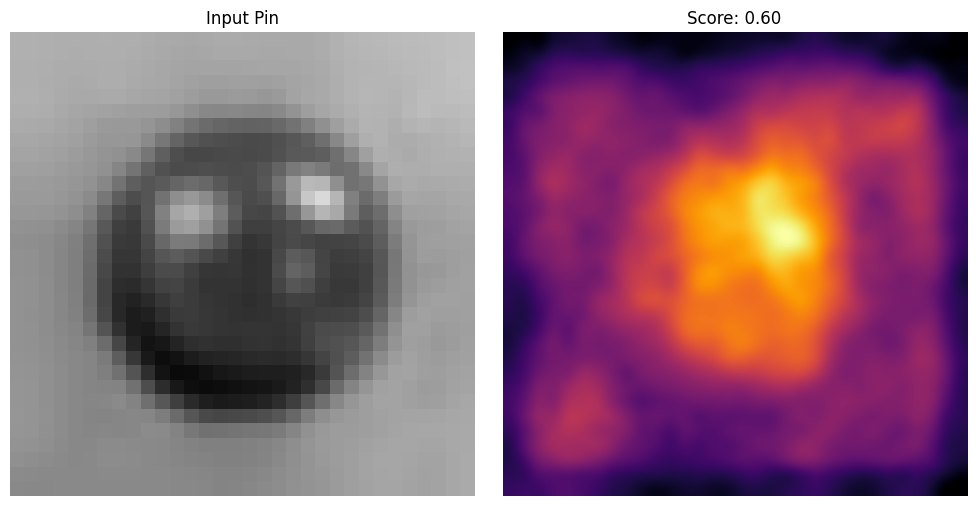

Good


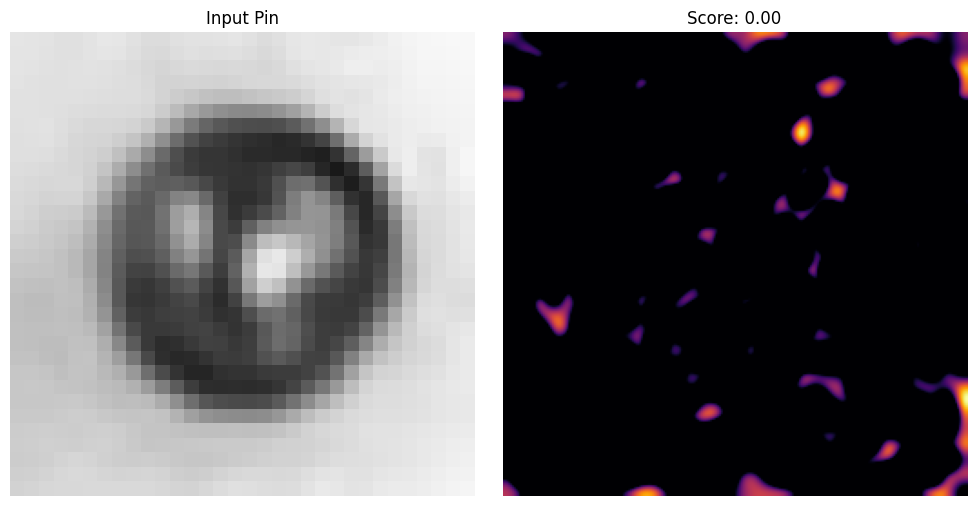

Anomalous


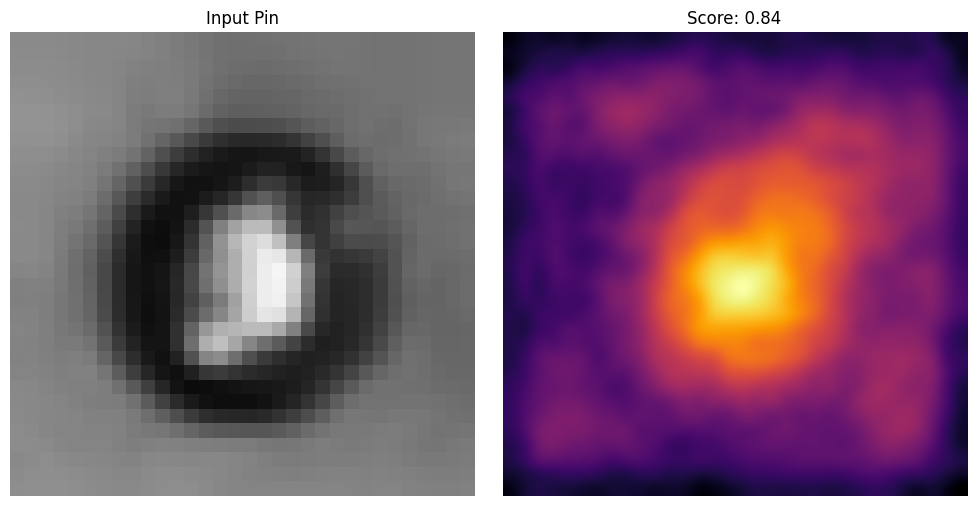

Anomalous


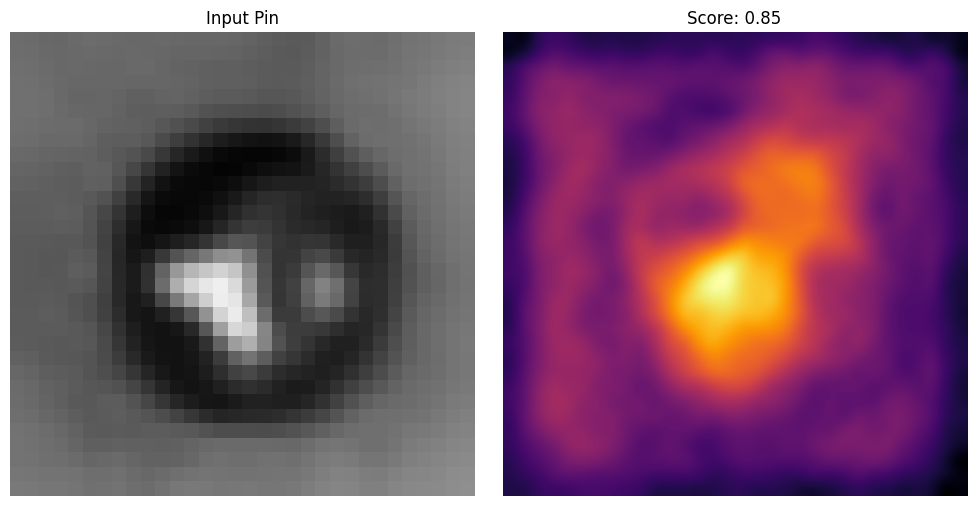

Anomalous


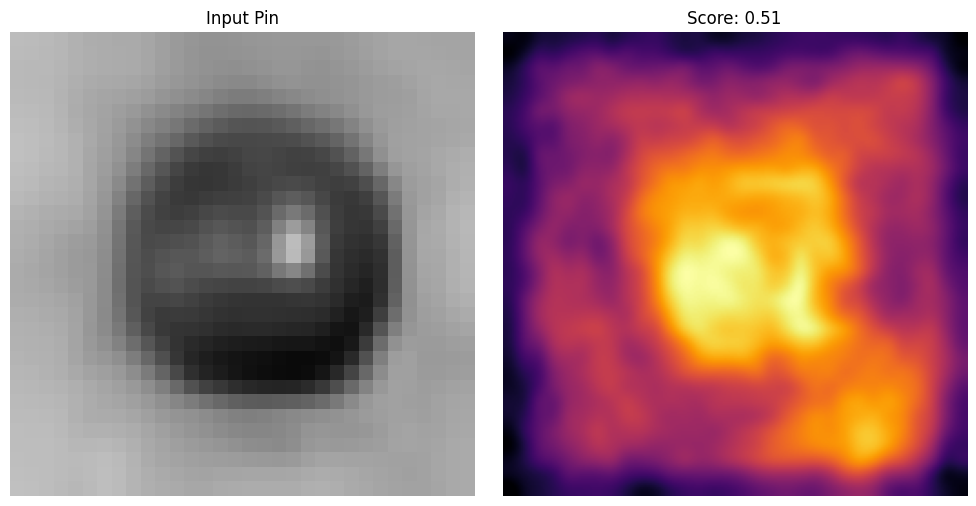

Anomalous


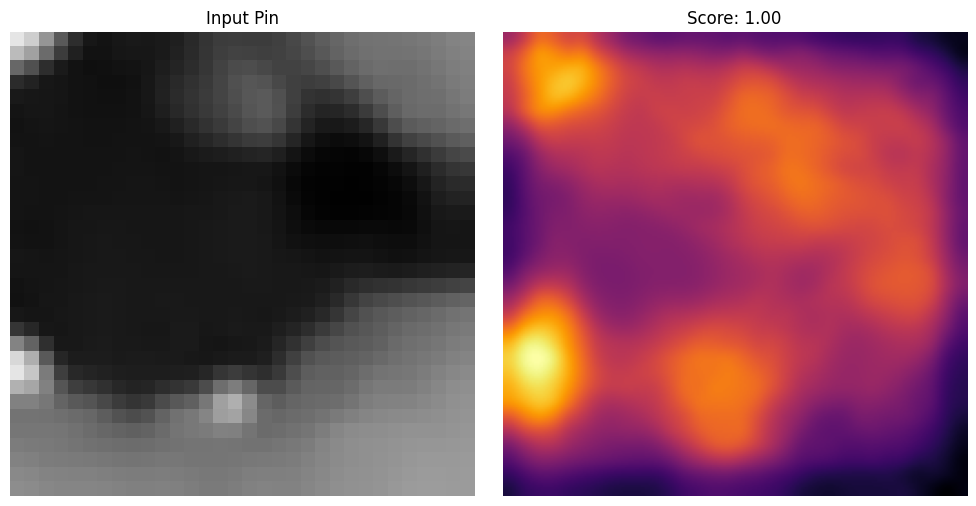

Good


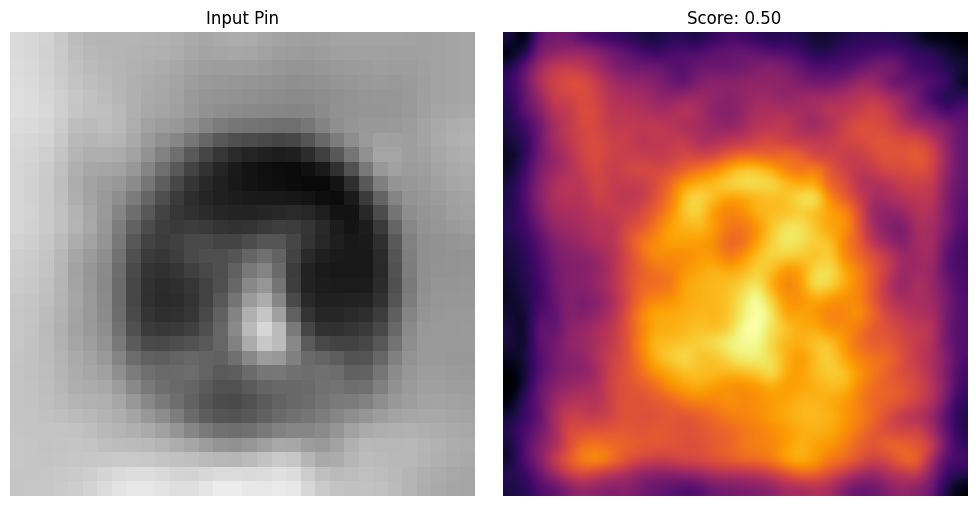

In [24]:
def inspect_pin(model_path, pin_image_path):
    inferencer = TorchInferencer(path=model_path, device="cpu")
    predictions = inferencer.predict(image=pin_image_path)
    
    # --- HANDLE HEATMAP SHAPE ---
    anom_map = predictions.anomaly_map
    if hasattr(anom_map, "cpu"): 
        anom_map = anom_map.cpu().numpy()
    anom_map = anom_map.squeeze() # Removes (1, 256, 256) -> (256, 256)

    # --- HANDLE SCORE FORMATTING ---
    # Convert Tensor to float using .item()
    score = predictions.pred_score.item() 

    if score > 0.5:
        print("Anomalous")
    else:
        print("Good")

    # Visualize
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    # Original Image
    ax[0].imshow(cv2.cvtColor(cv2.imread(pin_image_path), cv2.COLOR_BGR2RGB))
    ax[0].set_title("Input Pin")
    ax[0].axis('off')
    
    # Anomaly Heatmap
    ax[1].imshow(anom_map, cmap='inferno') 
    ax[1].set_title(f"Score: {score:.2f}") # Now valid because 'score' is a float
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

img_path = "./datasets/socket_pins/test/defect/"
for img in os.listdir(img_path):
    inspect_pin("./results/Patchcore/socket_pins/latest/weights/torch/model.pt", f"{img_path}{img}")